# PROJECT TITLE: ANALYZING THE IMPACT OF TEST PREPARATION ON STUDENTS PERFORMANCE USING HYPOTHESIS TEST

**AIM**:
The aim of this project is to analyze whether completing a test preparation course has a significant impact on student academic performance
using statistical hypothesis testing methods.

**OBJECTIVES**:
- To explore the students performance dataset and understand key variables affecting academic outcomes.
- To compare the performance of students who completed the test preparation course with those who did not.
- To apply a t-test to determine whether there is a significant difference in average scores between the two groups.
- To apply chi-square test to examine the relationship between test preparation and pass rates.
- To interpret results and draw a meaningful conclusion based on the statistical evidence.

# FILE UPLOAD

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_csv("student_performance_10000.csv")

In [58]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,master's degree,free/reduced,none,41,42,57
1,male,group E,associate's degree,standard,none,40,51,55
2,male,group E,high school,free/reduced,none,62,54,47
3,male,group D,some college,free/reduced,none,46,41,41
4,female,group A,some college,free/reduced,completed,74,79,66
...,...,...,...,...,...,...,...,...
9995,female,group B,some high school,free/reduced,none,58,60,70
9996,female,group A,master's degree,standard,none,63,54,51
9997,female,group E,associate's degree,free/reduced,completed,51,58,69
9998,female,group D,high school,standard,completed,71,76,60


# DATA CLEANING

In [15]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [16]:
df.info

<bound method DataFrame.info of       gender race/ethnicity parental level of education         lunch  \
0       male        group A             master's degree  free/reduced   
1       male        group E          associate's degree      standard   
2       male        group E                 high school  free/reduced   
3       male        group D                some college  free/reduced   
4     female        group A                some college  free/reduced   
...      ...            ...                         ...           ...   
9995  female        group B            some high school  free/reduced   
9996  female        group A             master's degree      standard   
9997  female        group E          associate's degree  free/reduced   
9998  female        group D                 high school      standard   
9999    male        group C                some college  free/reduced   

     test preparation course  math score  reading score  writing score  
0                 

In [17]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [18]:
df.duplicated().sum()

np.int64(7)

In [19]:
df = df.drop_duplicates()

In [20]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,master's degree,free/reduced,none,41,42,57
1,male,group E,associate's degree,standard,none,40,51,55
2,male,group E,high school,free/reduced,none,62,54,47
3,male,group D,some college,free/reduced,none,46,41,41
4,female,group A,some college,free/reduced,completed,74,79,66
...,...,...,...,...,...,...,...,...
9995,female,group B,some high school,free/reduced,none,58,60,70
9996,female,group A,master's degree,standard,none,63,54,51
9997,female,group E,associate's degree,free/reduced,completed,51,58,69
9998,female,group D,high school,standard,completed,71,76,60


In [40]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
average_score                  0
Pass                           0
dtype: int64

In [41]:
df.describe()

,math score,reading score,writing score,average_score
count,9993.000000,9993.000000,9993.000000,9993.000000
mean,61.287601,63.187431,64.326328,62.933787
std,12.213078,12.168560,12.228840,11.171001
min,30.000000,32.000000,33.000000,33.000000
25%,52.000000,54.000000,55.000000,54.666667
50%,61.000000,63.000000,64.000000,63.000000
75%,70.000000,72.000000,73.000000,71.000000
max,99.000000,99.000000,100.000000,97.000000


# TEXT TRANSFORMATION: LOWERCASE TO UPPERCASE

In [22]:
df = df.copy()
df["gender"] = df["gender"].str.capitalize()

In [23]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,Male,group A,master's degree,free/reduced,none,41,42,57
1,Male,group E,associate's degree,standard,none,40,51,55
2,Male,group E,high school,free/reduced,none,62,54,47
3,Male,group D,some college,free/reduced,none,46,41,41
4,Female,group A,some college,free/reduced,completed,74,79,66
...,...,...,...,...,...,...,...,...
9995,Female,group B,some high school,free/reduced,none,58,60,70
9996,Female,group A,master's degree,standard,none,63,54,51
9997,Female,group E,associate's degree,free/reduced,completed,51,58,69
9998,Female,group D,high school,standard,completed,71,76,60


In [24]:
df = df.copy()
df["race/ethnicity"] = df["race/ethnicity"].str.title()

In [25]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,Male,Group A,master's degree,free/reduced,none,41,42,57
1,Male,Group E,associate's degree,standard,none,40,51,55
2,Male,Group E,high school,free/reduced,none,62,54,47
3,Male,Group D,some college,free/reduced,none,46,41,41
4,Female,Group A,some college,free/reduced,completed,74,79,66
...,...,...,...,...,...,...,...,...
9995,Female,Group B,some high school,free/reduced,none,58,60,70
9996,Female,Group A,master's degree,standard,none,63,54,51
9997,Female,Group E,associate's degree,free/reduced,completed,51,58,69
9998,Female,Group D,high school,standard,completed,71,76,60


In [26]:
df = df.copy()
df["parental level of education"] = df["parental level of education"].str.replace("'s","s")

In [27]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,Male,Group A,masters degree,free/reduced,none,41,42,57
1,Male,Group E,associates degree,standard,none,40,51,55
2,Male,Group E,high school,free/reduced,none,62,54,47
3,Male,Group D,some college,free/reduced,none,46,41,41
4,Female,Group A,some college,free/reduced,completed,74,79,66
...,...,...,...,...,...,...,...,...
9995,Female,Group B,some high school,free/reduced,none,58,60,70
9996,Female,Group A,masters degree,standard,none,63,54,51
9997,Female,Group E,associates degree,free/reduced,completed,51,58,69
9998,Female,Group D,high school,standard,completed,71,76,60


In [28]:
df = df.copy()
df["parental level of education"] = df["parental level of education"].str.title()

In [29]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,Male,Group A,Masters Degree,free/reduced,none,41,42,57
1,Male,Group E,Associates Degree,standard,none,40,51,55
2,Male,Group E,High School,free/reduced,none,62,54,47
3,Male,Group D,Some College,free/reduced,none,46,41,41
4,Female,Group A,Some College,free/reduced,completed,74,79,66
...,...,...,...,...,...,...,...,...
9995,Female,Group B,Some High School,free/reduced,none,58,60,70
9996,Female,Group A,Masters Degree,standard,none,63,54,51
9997,Female,Group E,Associates Degree,free/reduced,completed,51,58,69
9998,Female,Group D,High School,standard,completed,71,76,60


In [30]:
df =df.copy()
df["lunch"] = df["lunch"].str.title()

In [31]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,Male,Group A,Masters Degree,Free/Reduced,none,41,42,57
1,Male,Group E,Associates Degree,Standard,none,40,51,55
2,Male,Group E,High School,Free/Reduced,none,62,54,47
3,Male,Group D,Some College,Free/Reduced,none,46,41,41
4,Female,Group A,Some College,Free/Reduced,completed,74,79,66
...,...,...,...,...,...,...,...,...
9995,Female,Group B,Some High School,Free/Reduced,none,58,60,70
9996,Female,Group A,Masters Degree,Standard,none,63,54,51
9997,Female,Group E,Associates Degree,Free/Reduced,completed,51,58,69
9998,Female,Group D,High School,Standard,completed,71,76,60


In [32]:
df = df.copy()
df["test preparation course"] = df["test preparation course"].str.capitalize()

In [33]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,Male,Group A,Masters Degree,Free/Reduced,None,41,42,57
1,Male,Group E,Associates Degree,Standard,None,40,51,55
2,Male,Group E,High School,Free/Reduced,None,62,54,47
3,Male,Group D,Some College,Free/Reduced,None,46,41,41
4,Female,Group A,Some College,Free/Reduced,Completed,74,79,66
...,...,...,...,...,...,...,...,...
9995,Female,Group B,Some High School,Free/Reduced,None,58,60,70
9996,Female,Group A,Masters Degree,Standard,None,63,54,51
9997,Female,Group E,Associates Degree,Free/Reduced,Completed,51,58,69
9998,Female,Group D,High School,Standard,Completed,71,76,60


**OBSERVATIONS**

- All columns are properly named.
- No missing values detected.

# CREATING NEW COLUMNS

In [34]:
df["average_score"] = (df["math score"] + df["reading score"] + df["writing score"])/3

In [35]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,Male,Group A,Masters Degree,Free/Reduced,None,41,42,57,46.666667
1,Male,Group E,Associates Degree,Standard,None,40,51,55,48.666667
2,Male,Group E,High School,Free/Reduced,None,62,54,47,54.333333
3,Male,Group D,Some College,Free/Reduced,None,46,41,41,42.666667
4,Female,Group A,Some College,Free/Reduced,Completed,74,79,66,73.000000
...,...,...,...,...,...,...,...,...,...
9995,Female,Group B,Some High School,Free/Reduced,None,58,60,70,62.666667
9996,Female,Group A,Masters Degree,Standard,None,63,54,51,56.000000
9997,Female,Group E,Associates Degree,Free/Reduced,Completed,51,58,69,59.333333
9998,Female,Group D,High School,Standard,Completed,71,76,60,69.000000


In [36]:
df["Pass"] = df["average_score"]. apply(lambda x:
                                        "pass" if x >=50 else "fail")

In [37]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,Pass
0,Male,Group A,Masters Degree,Free/Reduced,None,41,42,57,46.666667,fail
1,Male,Group E,Associates Degree,Standard,None,40,51,55,48.666667,fail
2,Male,Group E,High School,Free/Reduced,None,62,54,47,54.333333,pass
3,Male,Group D,Some College,Free/Reduced,None,46,41,41,42.666667,fail
4,Female,Group A,Some College,Free/Reduced,Completed,74,79,66,73.000000,pass
...,...,...,...,...,...,...,...,...,...,...
9995,Female,Group B,Some High School,Free/Reduced,None,58,60,70,62.666667,pass
9996,Female,Group A,Masters Degree,Standard,None,63,54,51,56.000000,pass
9997,Female,Group E,Associates Degree,Free/Reduced,Completed,51,58,69,59.333333,pass
9998,Female,Group D,High School,Standard,Completed,71,76,60,69.000000,pass


# DISTRIBUTION PLOT

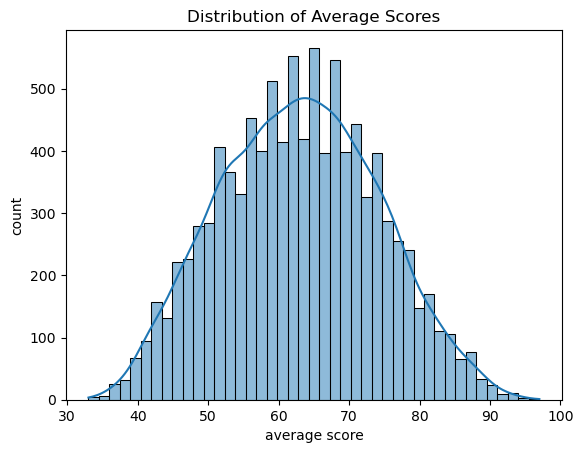

In [49]:
sns.histplot(df["average_score"], kde=True)
plt.title("Distribution of Average Scores")
plt.xlabel("average score")
plt.ylabel("count")
plt.show()

# DATA AGGREGATION USING GROUPBY

In [38]:
df.groupby("test preparation course")["average_score"].mean()

test preparation course
Completed    67.848461
None         57.964715
Name: average_score, dtype: float64

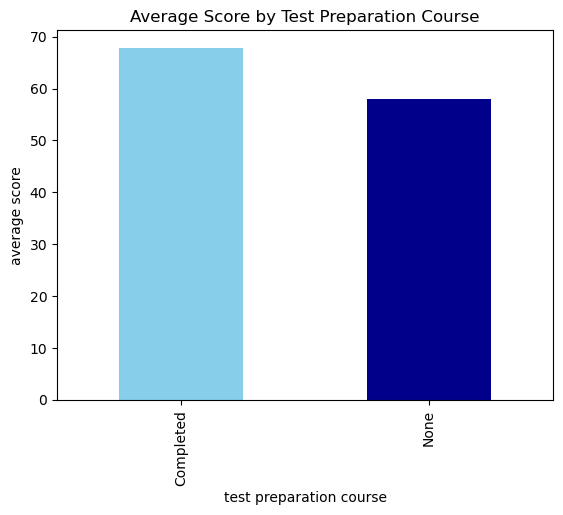

In [45]:
df.groupby("test preparation course")["average_score"].mean().plot(kind="bar",color =["skyblue","darkblue"])
plt.ylabel("average score")
plt.title("Average Score by Test Preparation Course")
plt.show()

Fig 1: Average score by Test preparation score. This chart shows the students who completed the test preparation course and those who did not.

In [50]:
df["Pass"].value_counts()

Pass
pass    8679
fail    1314
Name: count, dtype: int64

## HYPOTHESES

H0: Test preparation has no effect on students performance.

H1: Test preparation affects students performace.

# HYPOTHESIS TESTING

In [ ]:
from scipy.stats import ttest_ind
group1 = df[df["test preparation course"] == "none"]["average_score"]
group2 = df[df["test preparation course"] == "completed"]["average_score"]
t_stat, p_value = ttest_ind(group1,group2)
print("T-statistics:", t_stat)
print("P-value:", p_value)

# T TEST ANALYSIS

In [53]:
from scipy import stats
import numpy as np
sample1 = [4,5,6]
sample2 = [7]
additional_data =[8,9,10]
sample2.extend(additional_data)
print("sample1:", sample1)
print("sample2:", sample2)
t_stat, p_value = stats.ttest_ind(sample1, sample2)
print("t-statistics:", t_stat)
print("p-value:", p_value)

sample1: [4, 5, 6]
sample2: [7, 8, 9, 10]
t-statistics: -3.872983346207417
p-value: 0.011724811003954635


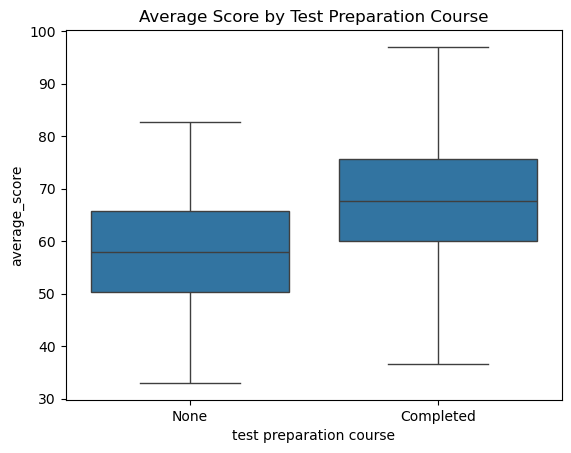

In [46]:
sns.boxplot(x="test preparation course", y="average_score", data=df)
plt.title("Average Score by Test Preparation Course")
plt.show()

Fig 2: Average score by test preparation course. Students who have completed the course scored higher, confirming the t-test findings.

# T TEST RESULT INTERPRETATION

The t-test yielded t = -3.87 and p = 0.0117. Since p<0.05, we reject H0.

Students who completed the testpreparation course have significantly higher average score than those who did not.

# CHI-SQUARE ANALYSIS

In [52]:
import pandas as pd
from scipy.stats import chi2_contingency
table = pd.crosstab(df["test preparation course"], df["Pass"])
chi2, p_value, dof, expected = chi2_contingency(table)
print("Chi-square:", chi2)
print("P-value:", p_value)

Chi-square: 970.212915883217
P-value: 5.357994154741118e-213


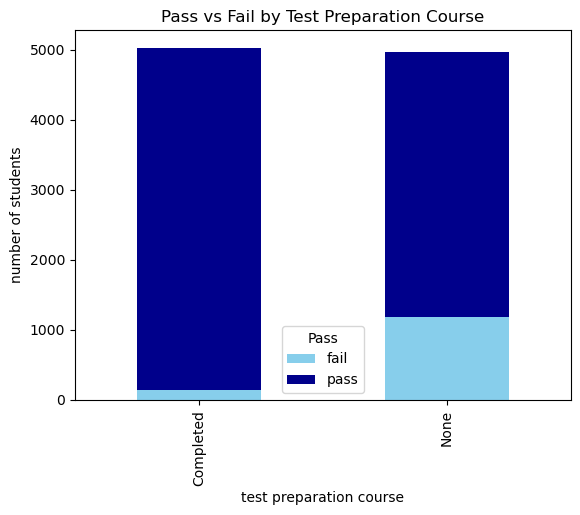

In [47]:
pd.crosstab(df["test preparation course"], df["Pass"]).plot(kind="bar", color=["skyblue","darkblue"],stacked =True)
plt.title("Pass vs Fail by Test Preparation Course")
plt.xlabel("test preparation course")
plt.ylabel("number of students")
plt.show()

Fig 3: Pass vs Fail by Test preparation course. Students who completed the course scored higher, confirming the chi-square findings.

# CHI-SQUARE RESULT INTERPRETATION

Chi-square = 970.21, p = 5.36e-213.

There is a significant association the passing status.

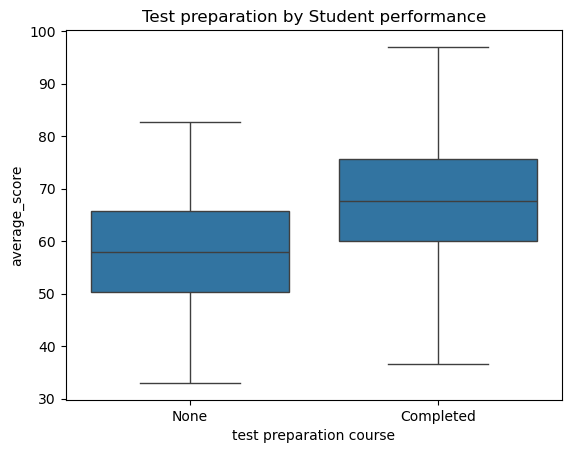

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x="test preparation course", y="average_score", data=df)
plt.title("Test preparation by Student performance")
plt.show()

Fig 4: Average score by Test preparation course. Students who completed the course scored higher.

## CONCLUSION

Based on the analysis of the student performance dataset, i concluded that:
1. Average Score Analysis(T-Test): The t-test yielded a t-statistical of -3.873 with a p-value of 0.0117, which is less than the significance
level of 0.05. This indicate that there is a statistical effect in average scores between students who completed the test preparation course
and those who did not.
2. Pass/Fail Analysis(Chi-square Test): The chi-square test produced a chi-square statistic of 970.21 with an extremely small p-value(<0.05),
indicating a significant difference between completing a test preparation course and passing the exam.

Both test confirms that completing a test preparation course has a positive effect on student performance. Students who completed the course scored higher on average and were more likely to pass the exam compared to students who did not complete the course. 
Therefore, i reject this null hypothesis.

## RECOMMENDATION

- Encourage test prepation course
- Implement support system